LSTM NEXT WORD PREDICTION - BEGINNER FRIENDLY GUIDE             
                                                                            
  This script implements a complete LSTM model for predicting the next     
  word in a sequence.

# STEP 1: IMPORT REQUIRED LIBRARIES


In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!\n")

✓ All libraries imported successfully!



# STEP 2: LOAD SAMPLE DATASET

In [2]:
with open('/content/drive/MyDrive/Colab Notebooks/LSTM Assignment/LSTM DATA.txt', 'r') as file:
    text_data = file.read()
df = pd.DataFrame([text_data], columns=['text']) # Wrap in DataFrame for consistency with other pandas operations
print("✓ Text data loaded successfully into a DataFrame!")
print(df.head())

✓ Text data loaded successfully into a DataFrame!
                                                text
0  ﻿The Project Gutenberg eBook of Pride and Prej...


In [3]:
print("📚 Dataset Information:")
print(f"   - Number of characters: {len(text_data)}")
print(f"   - Number of words (approx): {len(text_data.split())}")
print("\n✓ Dataset loaded successfully!\n")

📚 Dataset Information:
   - Number of characters: 748151
   - Number of words (approx): 130408

✓ Dataset loaded successfully!



# STEP 3: DATA PREPROCESSING

In [4]:
print("=" * 80)
print("STEP 3: DATA PREPROCESSING")
print("=" * 80)

print("\n[3.1] Cleaning Text...")
text = text_data.lower()
text = ' '.join(text.split())
print(f"   ✓ Text cleaned: {len(text)} characters")
print(f"   ✓ First 100 characters: {text[:100]}...\n")

print("[3.2] Tokenizing Text...")
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts([text])
vocab_size = len(tokenizer.word_index) + 1
print(f"   ✓ Vocabulary size: {vocab_size} unique words")
print(f"   ✓ Sample token mapping (first 10 words):")

sample_words = list(tokenizer.word_index.items())[:10]
for word, idx in sample_words:
    print(f"      '{word}' → {idx}")
print()

print("[3.3] Converting Text to Sequences...")
sequences = tokenizer.texts_to_sequences([text])[0]
print(f"   ✓ Converted to {len(sequences)} numerical tokens")
print(f"   ✓ First 20 tokens: {sequences[:20]}\n")

STEP 3: DATA PREPROCESSING

[3.1] Cleaning Text...
   ✓ Text cleaned: 737519 characters
   ✓ First 100 characters: ﻿the project gutenberg ebook of pride and prejudice this ebook is for the use of anyone anywhere in ...

[3.2] Tokenizing Text...
   ✓ Vocabulary size: 7562 unique words
   ✓ Sample token mapping (first 10 words):
      '<OOV>' → 1
      'the' → 2
      'to' → 3
      'of' → 4
      'and' → 5
      'her' → 6
      'a' → 7
      'in' → 8
      'was' → 9
      'i' → 10

[3.3] Converting Text to Sequences...
   ✓ Converted to 132957 numerical tokens
   ✓ First 20 tokens: [4533, 190, 452, 1030, 4, 305, 5, 976, 43, 1030, 25, 23, 2, 516, 4, 561, 2721, 8, 2, 702]



# STEP 4: GENERATE TRAINING DATA

In [5]:
seq_length = 3
print(f"\nSequence Length: {seq_length} (predict the next word from {seq_length} words)")

X_train = []
y_train = []

print("\n[4.1] Creating Input-Output Pairs...")

for i in range(len(sequences) - seq_length):
    x_seq = sequences[i:i + seq_length]
    y_val = sequences[i + seq_length]
    X_train.append(x_seq)
    y_train.append(y_val)

X_train = np.array(X_train)
y_train = np.array(y_train)


Sequence Length: 3 (predict the next word from 3 words)

[4.1] Creating Input-Output Pairs...


In [6]:
len(X_train)

132954

In [7]:
X_train.shape

(132954, 3)

In [8]:
y_train.shape

(132954,)

# STEP 5: BUILD THE LSTM MODEL

In [9]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_shape=(seq_length,)))
model.add(LSTM(units=100, return_sequences=False))
model.add(Dropout(rate=0.2))
model.add(Dense(units=vocab_size, activation='softmax'))

In [10]:
model.compile(loss='sparse_categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 3, 128)         │       967,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7562)           │       763,762 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,823,298 (6.96 MB)

 Trainable params: 1,823,298 (6.96 MB)

 Non-trainable params: 0 (0.00 B)

# STEP 6: TRAIN THE MODEL

In [12]:
print("\n[6.1] Training Configuration:")
print(f"   - Epochs: 50")
print(f"   - Batch Size: 64")
print(f"   - Validation Split: 0.2")
print(f"   - Early Stopping: Enabled\n")

early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

history = model.fit(X_train, y_train,epochs=50,batch_size=64,validation_split=0.2,callbacks=[early_stop],verbose=1)





[6.1] Training Configuration:
   - Epochs: 50
   - Batch Size: 64
   - Validation Split: 0.2
   - Early Stopping: Enabled

Epoch 1/50
1662/1662 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.0498 - loss: 6.3525 - val_accuracy: 0.0670 - val_loss: 6.1769
Epoch 2/50
1662/1662 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.0911 - loss: 5.7446 - val_accuracy: 0.1068 - val_loss: 5.7779
Epoch 3/50
1662/1662 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.1198 - loss: 5.3627 - val_accuracy: 0.1204 - val_loss: 5.6195
Epoch 4/50
1662/1662 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.1354 - loss: 5.1242 - val_accuracy: 0.1258 - val_loss: 5.5528
Epoch 5/50
1662/1662 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.1471 - loss: 4.9455 - val_accuracy: 0.1321 - val_loss: 5.5272
Epoch 6/50
1662/1662 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.1568 - loss: 4.7961 - val_accuracy: 0.1349 - val_loss: 5.5315
Epoch 7/50
1662/1662 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.1657 - loss: 4.6624 -

# STEP 7: EVALUATE THE MODE

In [13]:
val_loss = history.history['val_loss'][-1]
val_accuracy = history.history['val_accuracy'][-1]
train_accuracy = history.history['accuracy'][-1]

print(f"\n[7.1] Performance Metrics:")
print(f"   ✓ Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   ✓ Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"   ✓ Validation Loss: {val_loss:.4f}")

overfitting = train_accuracy - val_accuracy
print(f"\n[7.2] Overfitting Analysis:")
print(f"   ✓ Difference (Train - Val): {overfitting:.4f}")
if overfitting > 0.1:
    print(f"   ⚠ Model shows signs of overfitting")
else:
    print(f"   ✓ Model generalizes well\n")


[7.1] Performance Metrics:
   ✓ Training Accuracy: 0.1886 (18.86%)
   ✓ Validation Accuracy: 0.1400 (14.00%)
   ✓ Validation Loss: 5.6398

[7.2] Overfitting Analysis:
   ✓ Difference (Train - Val): 0.0487
   ✓ Model generalizes well



# STEP 8: VISUALIZE TRAINING HISTORY

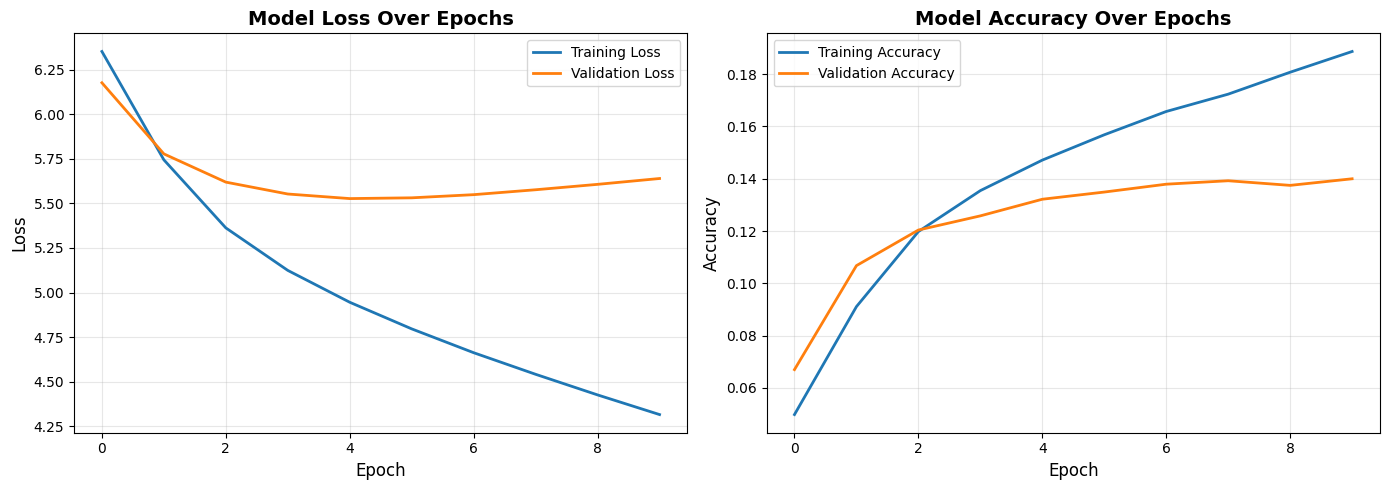


✓ Training visualization saved!



In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training visualization saved!\n")

# STEP 9: PREDICT NEXT WORD

In [15]:
def predict_next_word(model, tokenizer, text, seq_length=3):
    """Predict the next word in a sequence"""

    print(f"\n[Input]: '{text}'")

    tokens = tokenizer.texts_to_sequences([text])[0]
    print(f"[Tokens]: {tokens}")

    tokens = tokens[-seq_length:]
    tokens = pad_sequences([tokens], maxlen=seq_length, padding='pre')[0]

    prediction = model.predict(np.array([tokens]), verbose=0)
    predicted_idx = np.argmax(prediction[0])
    confidence = np.max(prediction[0])

    reverse_word_map = {v: k for k, v in tokenizer.word_index.items()}
    predicted_word = reverse_word_map.get(predicted_idx, '<unknown>')

    print(f"[Predicted Word]: '{predicted_word}'")
    print(f"[Confidence]: {confidence*100:.2f}%")

    print("\n[Top 5 Predictions]:")
    top_indices = np.argsort(prediction[0])[-5:][::-1]
    for rank, idx in enumerate(top_indices, 1):
        word = reverse_word_map.get(idx, '<unknown>')
        prob = prediction[0][idx]
        print(f"   {rank}. '{word}': {prob*100:.2f}%")

    return predicted_word, confidence

    #Test predictions
test_inputs = [
    "the quick brown",
    "fresh air is",
]

for test_input in test_inputs:
    if all(word in text for word in test_input.split()):
        predict_next_word(model, tokenizer, test_input, seq_length=seq_length)
    else:
        print(f"\n⚠ '{test_input}' not found in training data")


[Input]: 'the quick brown'
[Tokens]: [2, 1269, 1]
[Predicted Word]: 'of'
[Confidence]: 15.07%

[Top 5 Predictions]:
   1. 'of': 15.07%
   2. 'and': 6.15%
   3. 'which': 4.31%
   4. 'in': 2.94%
   5. 'the': 2.41%

[Input]: 'fresh air is'
[Tokens]: [1244, 539, 25]
[Predicted Word]: 'not'
[Confidence]: 2.49%

[Top 5 Predictions]:
   1. 'not': 2.49%
   2. 'a': 1.59%
   3. 'very': 1.36%
   4. '<OOV>': 0.98%
   5. 'to': 0.98%


# STEP 10: GENERATE SENTENCES

In [16]:
def generate_sentence(model, tokenizer, seed_text, num_words=5, seq_length=3):
    """Generate a sentence by predicting multiple words"""

    print(f"\n[Seed Text]: '{seed_text}'")
    print(f"[Generating {num_words} words]...\n")

    current_text = seed_text
    generated_words = []
    reverse_word_map = {v: k for k, v in tokenizer.word_index.items()}

    for i in range(num_words):
        tokens = tokenizer.texts_to_sequences([current_text])[0]
        tokens = tokens[-seq_length:]
        tokens = pad_sequences([tokens], maxlen=seq_length, padding='pre')[0]

        prediction = model.predict(np.array([tokens]), verbose=0)
        predicted_idx = np.argmax(prediction[0])
        predicted_word = reverse_word_map.get(predicted_idx, '<unknown>')

        generated_words.append(predicted_word)
        current_text += f" {predicted_word}"

        print(f"   Step {i+1}: + '{predicted_word}'")

    print(f"\n[Generated Sentence]: {current_text}\n")
    return current_text

In [17]:
# Generate sample sentences
seed_texts = ["the quick brown", "fresh air"]

for seed in seed_texts:
    if all(word in text for word in seed.split()):
        generate_sentence(model, tokenizer, seed, num_words=5, seq_length=seq_length)


[Seed Text]: 'the quick brown'
[Generating 5 words]...

   Step 1: + 'of'
   Step 2: + 'the'
   Step 3: + '<OOV>'
   Step 4: + 'of'
   Step 5: + 'the'

[Generated Sentence]: the quick brown of the <OOV> of the


[Seed Text]: 'fresh air'
[Generating 5 words]...

   Step 1: + 'and'
   Step 2: + '<OOV>'
   Step 3: + 'of'
   Step 4: + 'the'
   Step 5: + '<OOV>'

[Generated Sentence]: fresh air and <OOV> of the <OOV>



# STEP 11: SAVE THE MODEL

In [18]:
print("\n[11.1] Saving Model Files...")

model.save('lstm_next_word_model.h5')
print("   ✓ Model saved as 'lstm_next_word_model.h5'")

import json
tokenizer_json = tokenizer.to_json()
with open('tokenizer.json', 'w') as f:
    json.dump(tokenizer_json, f)
print("   ✓ Tokenizer saved as 'tokenizer.json'")

config = {
    'seq_length': seq_length,
    'vocab_size': vocab_size,
    'embedding_dim': 128,
    'lstm_units': 100,
    'dropout_rate': 0.2
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print("   ✓ Configuration saved as 'model_config.json'")

print("\n✓ All files saved successfully!\n")


[11.1] Saving Model Files...
   ✓ Model saved as 'lstm_next_word_model.h5'
   ✓ Tokenizer saved as 'tokenizer.json'
   ✓ Configuration saved as 'model_config.json'

✓ All files saved successfully!



# COMPLETION SUMMARY

In [19]:
print("=" * 80)
print("🎉 PROJECT COMPLETED!")
print("=" * 80)

print(f"""

                       FINAL SUMMARY



  ✓ Data Preparation:
    - Vocabulary: {vocab_size} unique words                                                                                                             ║
  ✓ Feature Engineering:
    - Training sequences: {len(X_train)}
    - Sequence length: {seq_length} words

  ✓ Model Performance:
    - Training Accuracy: {train_accuracy*100:.2f}%
    - Validation Accuracy: {val_accuracy*100:.2f}%

  ✓ Generated Outputs:
    - lstm_next_word_model.h5  (Trained model)
    - tokenizer.json             (Vocabulary mapping)
    - model_config.json          (Hyperparameters)
    - training_history.png       (Performance graph)


""")

print("✨ Thank you for using this LSTM tutorial! ✨")
print("=" * 80)


🎉 PROJECT COMPLETED!


                       FINAL SUMMARY



  ✓ Data Preparation:
    - Vocabulary: 7562 unique words                                                                                                             ║
  ✓ Feature Engineering:
    - Training sequences: 132954
    - Sequence length: 3 words

  ✓ Model Performance:
    - Training Accuracy: 18.86%
    - Validation Accuracy: 14.00%

  ✓ Generated Outputs:
    - lstm_next_word_model.h5  (Trained model)
    - tokenizer.json             (Vocabulary mapping)
    - model_config.json          (Hyperparameters)
    - training_history.png       (Performance graph)



✨ Thank you for using this LSTM tutorial! ✨
